<a href="https://colab.research.google.com/github/nxtirfan/Wine-Classification/blob/main/UTS_PDAB_Irfan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality Prediction Pipeline for Imbalanced Multiclass Classification

#### UTS Penambangan Data dan Analisis Bisnis • UNNES • 2025/2026

---

**Daftar Isi**

1. [Pendahuluan](#1-pendahuluan)
2. [Inisialisasi dan Pemuatan Data](#2-inisialisasi)
3. [Exploratory Data Analysis](#3-eda)
4. [Persiapan Data](#4-persiapan)
5. [Feature Engineering](#5-fe)
6. [Feature Scaling](#6-scaling)
7. [Handling Imbalanced Data dengan SMOTE](#7-smote)
8. [Perbandingan dan Pemilihan Model](#8-model)
9. [Evaluasi Model dengan OOF](#9-evaluasi)
10. [Prediksi Data dan Submission](#10-prediksi)
11. [Feature Importance](#11-importance)
12. [Kesimpulan](#12-kesimpulan)

---

## 1. Pendahuluan <a name="1-pendahuluan"></a>

Notebook ini dibuat untuk menyelesaikan permasalahan klasifikasi multikelas pada dataset kualitas anggur. Variabel target yang diprediksi adalah `quality`, yaitu skor kualitas wine berdasarkan karakteristik fisikokimia.

Terdapat dua karakteristik utama dataset yang memengaruhi seluruh rancangan pipeline pemodelan.

Pertama, distribusi kelas bersifat tidak seimbang. Sebagian besar observasi berada pada kualitas 5 dan 6, sedangkan kualitas 3 dan 8 hanya memiliki sedikit sampel. Kondisi ini menyebabkan model berisiko terlalu fokus mempelajari pola kelas mayoritas dan mengabaikan kelas minoritas.

Kedua, beberapa fitur memiliki rentang nilai yang sangat berbeda. Variabel seperti `residual sugar` dan `total sulfur dioxide` memiliki variasi jauh lebih besar dibanding `pH` maupun `density`. Perbedaan skala ini menjadi penting karena metode SMOTE menggunakan konsep jarak antar titik data saat membentuk sampel sintetis.

Selain ketidakseimbangan kelas, permasalahan klasifikasi pada dataset wine juga menjadi lebih sulit karena batas antar kualitas tidak bersifat tegas. Kualitas wine merupakan hasil evaluasi sensorik yang dipengaruhi banyak faktor kimia secara simultan sehingga dua wine dengan kualitas berdekatan dapat memiliki karakteristik fisikokimia yang sangat mirip.

Akibatnya, model tidak hanya harus mengenali pola tiap kelas, tetapi juga membedakan area distribusi yang saling overlap, terutama antara quality 5, 6, dan 7.

Karena itu, seluruh proses preprocessing dan evaluasi dirancang agar:

* tidak terjadi data leakage,
* evaluasi tetap realistis,
* dan hasil model dapat dijelaskan secara metodologis.

Alur pipeline yang digunakan adalah:
```
Load Data
   ↓
Exploratory Data Analysis
   ↓
Pemisahan Feature dan Target
   ↓
Feature Engineering
   ↓
Feature Scaling
   ↓
SMOTE dalam Pipeline Cross Validation
   ↓
Perbandingan Model
   ↓
Pemilihan Model Terbaik
   ↓
OOF Evaluation
   ↓
Prediksi Data Testing
   ↓
Pembuatan File Submission
```

---

## 2. Inisialisasi dan Pemuatan Data <a name="2-inisialisasi"></a>

### 2.1 Import Library

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Library yang digunakan mencakup:

* manipulasi data,
* visualisasi,
* preprocessing,
* penanganan imbalance,
* hingga pemodelan machine learning.

### 2.2 Load Dataset

Dataset training dan testing dipisahkan sejak awal agar data testing benar-benar menjadi data yang belum pernah dilihat model selama proses pembelajaran.

Pemisahan sejak awal juga mencegah distribusi data testing ikut memengaruhi preprocessing seperti scaling maupun feature engineering.

In [32]:
df_train = pd.read_csv(
    '/content/drive/Othercomputers/My Computer/Kuliah/5_Penambangan Data/'
    'M8 - UTS - 1 Mei 2026/Dataset UTS/data_training.csv'
)
df_test = pd.read_csv(
    '/content/drive/Othercomputers/My Computer/Kuliah/5_Penambangan Data/'
    'M8 - UTS - 1 Mei 2026/Dataset UTS/data_testing.csv'
)

print("Shape df_train:", df_train.shape)
print("Shape df_test :", df_test.shape)
display(df_train.head())

Shape df_train: (857, 13)
Shape df_test : (286, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


---

## 3. Exploratory Data Analysis <a name="3-eda"></a>

### 3.1 Missing Value

In [24]:
print("=== Missing Values (Training) ===")
print(df_train.isnull().sum())
print("\n=== Missing Values (Testing) ===")
print(df_test.isnull().sum())

=== Missing Values (Training) ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

=== Missing Values (Testing) ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


Seluruh fitur pada dataset training tidak memiliki missing value sehingga tidak diperlukan proses imputasi tambahan.

Dengan tidak adanya missing value, proses preprocessing dapat difokuskan pada distribusi fitur, imbalance kelas, dan hubungan antar variabel.

### 3.2 Distribusi Kelas Target

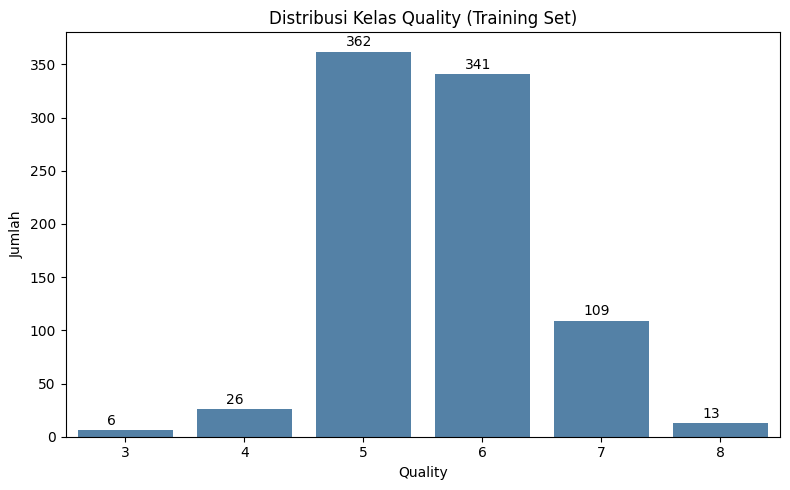


Distribusi absolut:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64

Distribusi relatif (%):
quality
3     0.7
4     3.0
5    42.2
6    39.8
7    12.7
8     1.5
Name: proportion, dtype: float64


In [25]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='quality', data=df_train, color='steelblue')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + 0.25, p.get_height() + 5))
plt.title('Distribusi Kelas Quality (Training Set)')
plt.xlabel('Quality'); plt.ylabel('Jumlah')
plt.tight_layout(); plt.show()

print("\nDistribusi absolut:")
print(df_train['quality'].value_counts().sort_index())
print("\nDistribusi relatif (%):")
print((df_train['quality'].value_counts(normalize=True).sort_index() * 100).round(1))

Distribusi kelas terlihat tidak seimbang. Kelas kualitas 5 dan 6 mendominasi dataset, sedangkan kualitas 3 dan 8 memiliki jumlah observasi jauh lebih sedikit.

Kondisi ini penting karena model dapat memperoleh accuracy cukup tinggi hanya dengan terus memprediksi kelas mayoritas.

Akibatnya, accuracy saja tidak cukup untuk mengevaluasi performa model pada dataset seperti ini. Oleh karena itu, pada tahap evaluasi juga digunakan Macro F1-Score agar performa pada kelas minoritas tetap diperhatikan.

Selain itu, pada tahap modeling akan dicoba:

* `class_weight='balanced'`
* serta SMOTE di dalam pipeline cross validation.

### 3.3 Statistik Deskriptif

In [26]:
display(df_train.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Beberapa fitur memiliki rentang nilai yang cukup lebar, terutama:

* `residual sugar`
* `free sulfur dioxide`
* `total sulfur dioxide`

Perbedaan skala antar fitur menjadi penting terutama karena pipeline menggunakan SMOTE yang bekerja berdasarkan jarak antar observasi.

Tanpa scaling, fitur dengan variance besar seperti `total sulfur dioxide` atau `residual sugar` dapat mendominasi perhitungan jarak Euclidean sehingga observasi dianggap mirip hanya karena salah satu fitur tersebut memiliki nilai besar.

Kondisi tersebut dapat menyebabkan pembentukan sampel sintetis yang kurang representatif terhadap struktur distribusi asli data.

Selain itu, beberapa fitur juga memiliki standar deviasi tinggi yang mengindikasikan kemungkinan skewness maupun outlier.

### 3.4 Korelasi Fitur

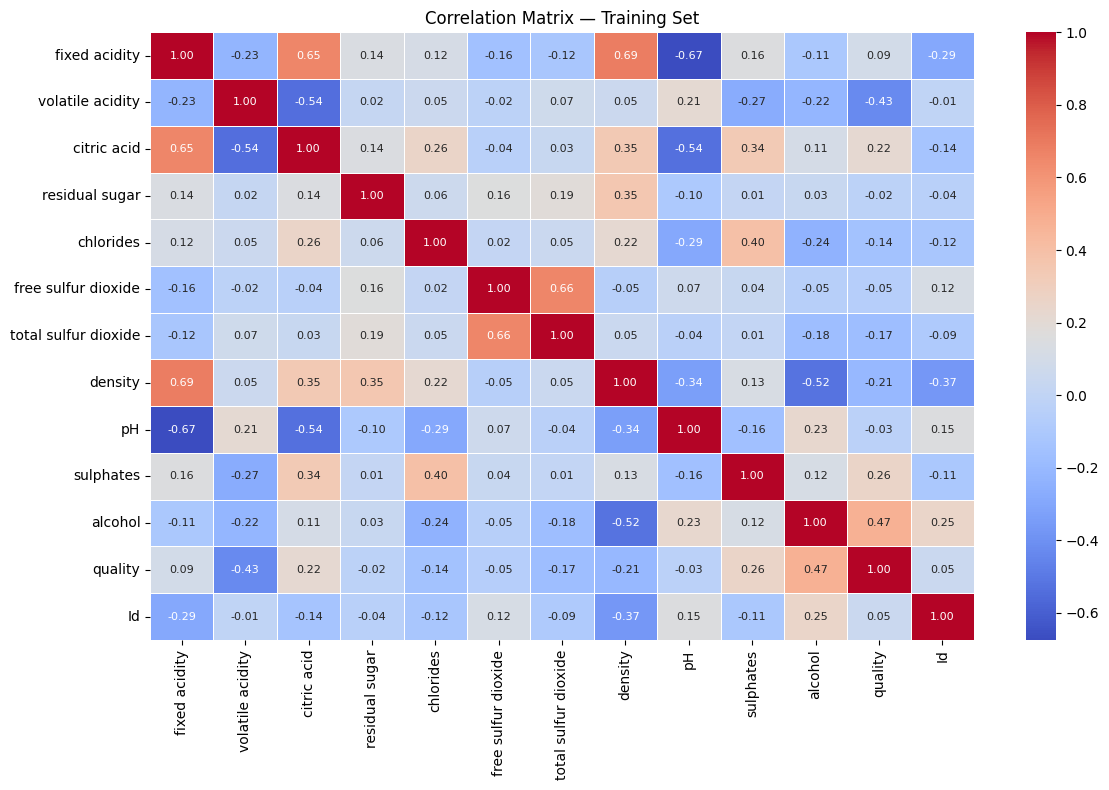


Korelasi fitur terhadap target quality (diurutkan):
alcohol                 0.473555
sulphates               0.260703
citric acid             0.221263
fixed acidity           0.092714
residual sugar         -0.020511
pH                     -0.033199
free sulfur dioxide    -0.054509
chlorides              -0.144946
total sulfur dioxide   -0.172737
density                -0.207903
volatile acidity       -0.430059


In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_train.corr(), cmap='coolwarm', annot=True, fmt='.2f',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix — Training Set')
plt.tight_layout(); plt.show()

print("\nKorelasi fitur terhadap target quality (diurutkan):")
feature_cols = [c for c in df_train.columns if c not in ['quality', 'Id']]
print(df_train[feature_cols + ['quality']].corr()['quality'].drop('quality')
        .sort_values(ascending=False).to_string())

Beberapa pola penting yang terlihat:

* `alcohol` memiliki korelasi positif terhadap `quality`
* `volatile acidity` berkorelasi negatif terhadap `quality`
* `density` memiliki hubungan kuat dengan `alcohol`

Hasil tersebut cukup konsisten secara domain karena kadar alkohol yang lebih tinggi sering dikaitkan dengan kualitas wine yang lebih baik, sedangkan volatile acidity yang tinggi dapat menghasilkan rasa menyerupai cuka.

Hubungan negatif kuat antara `density` dan `alcohol` juga menjadi dasar pembuatan fitur rasio pada tahap feature engineering.

### 3.5 Distribusi Fitur

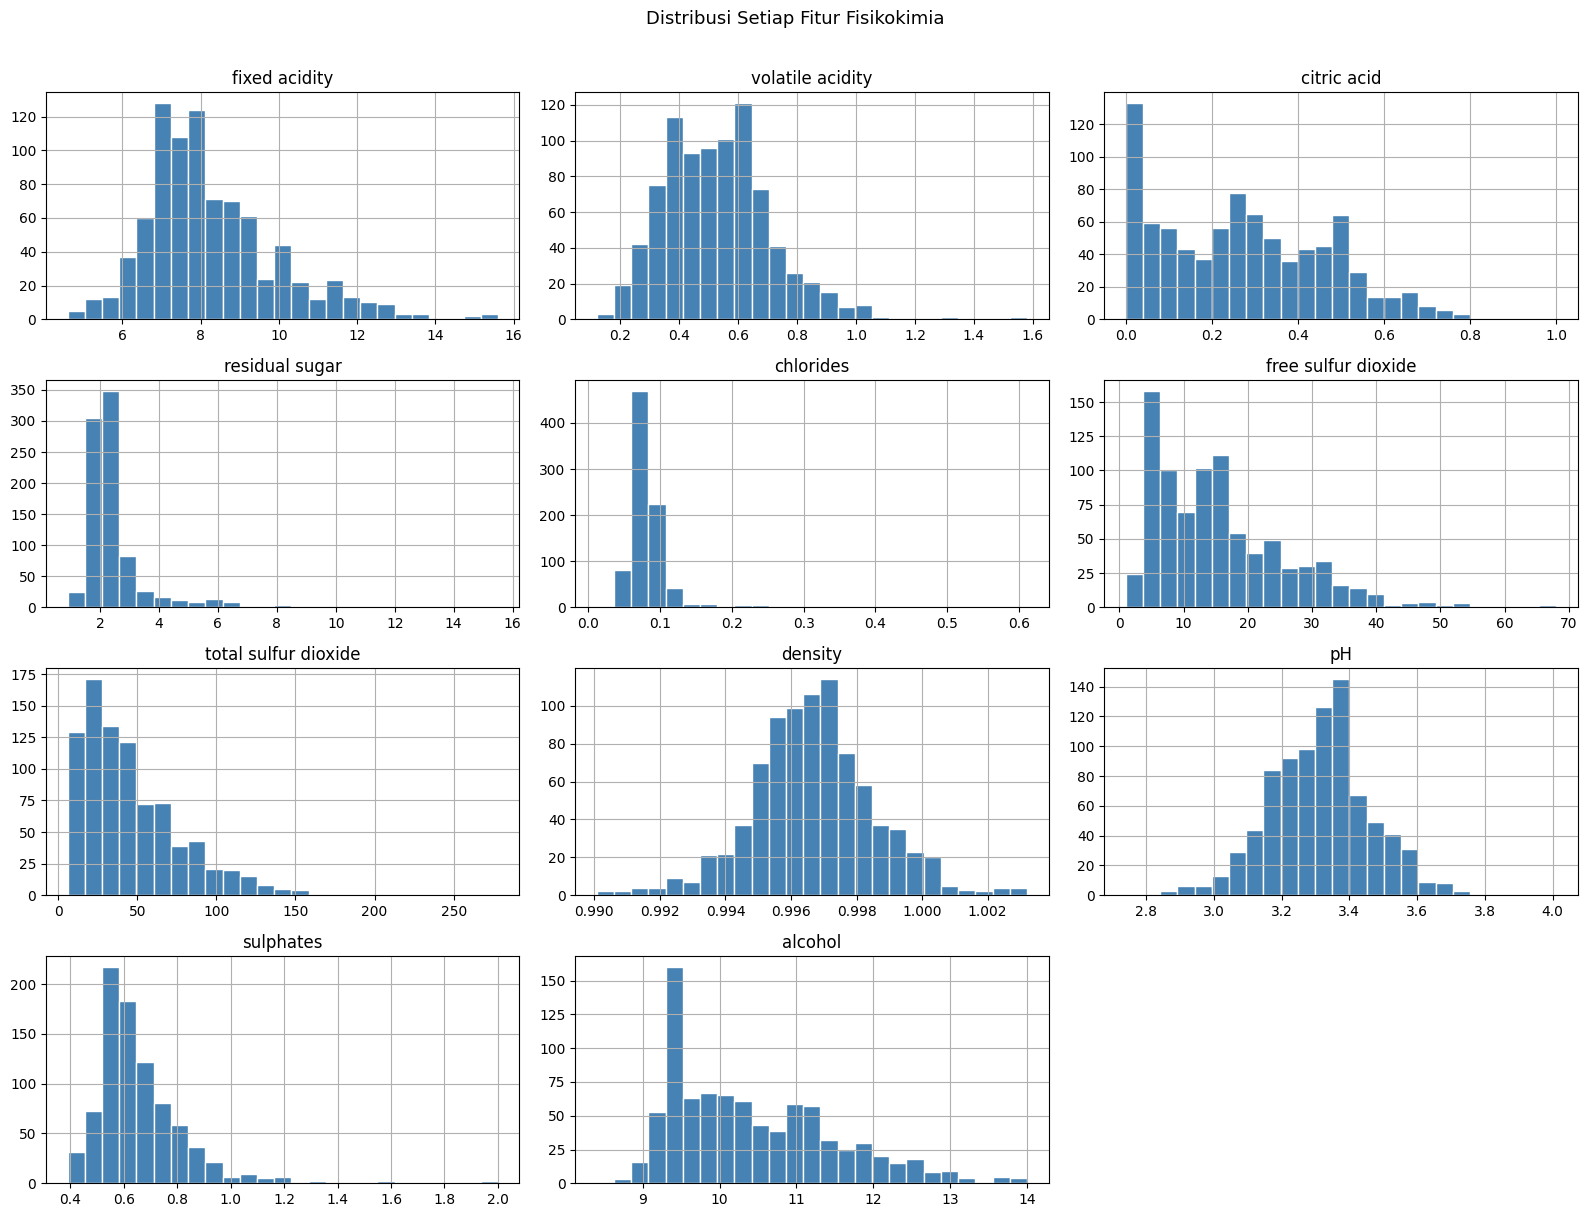

In [28]:
df_train[feature_cols].hist(figsize=(16, 12), bins=25, color='steelblue',
                            edgecolor='white')
plt.suptitle('Distribusi Setiap Fitur Fisikokimia', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

Sebagian fitur terlihat tidak berdistribusi normal dan memiliki skewness cukup tinggi.

Hal ini terutama terlihat pada:

* `residual sugar`
* `chlorides`
* `sulfur dioxide`

Distribusi yang sangat skewed menunjukkan bahwa sebagian besar observasi terkonsentrasi pada area tertentu, sementara sebagian kecil lainnya berada jauh pada ekor distribusi.

Dalam konteks SMOTE, kondisi ini penting karena pembentukan sampel sintetis dilakukan melalui interpolasi antar tetangga terdekat.

Jika observasi minoritas berada dekat area outlier atau ekor distribusi, maka sampel sintetis yang dihasilkan berpotensi terbentuk pada area yang sebenarnya jarang muncul pada distribusi asli data.

### 3.6 Deteksi Outlier

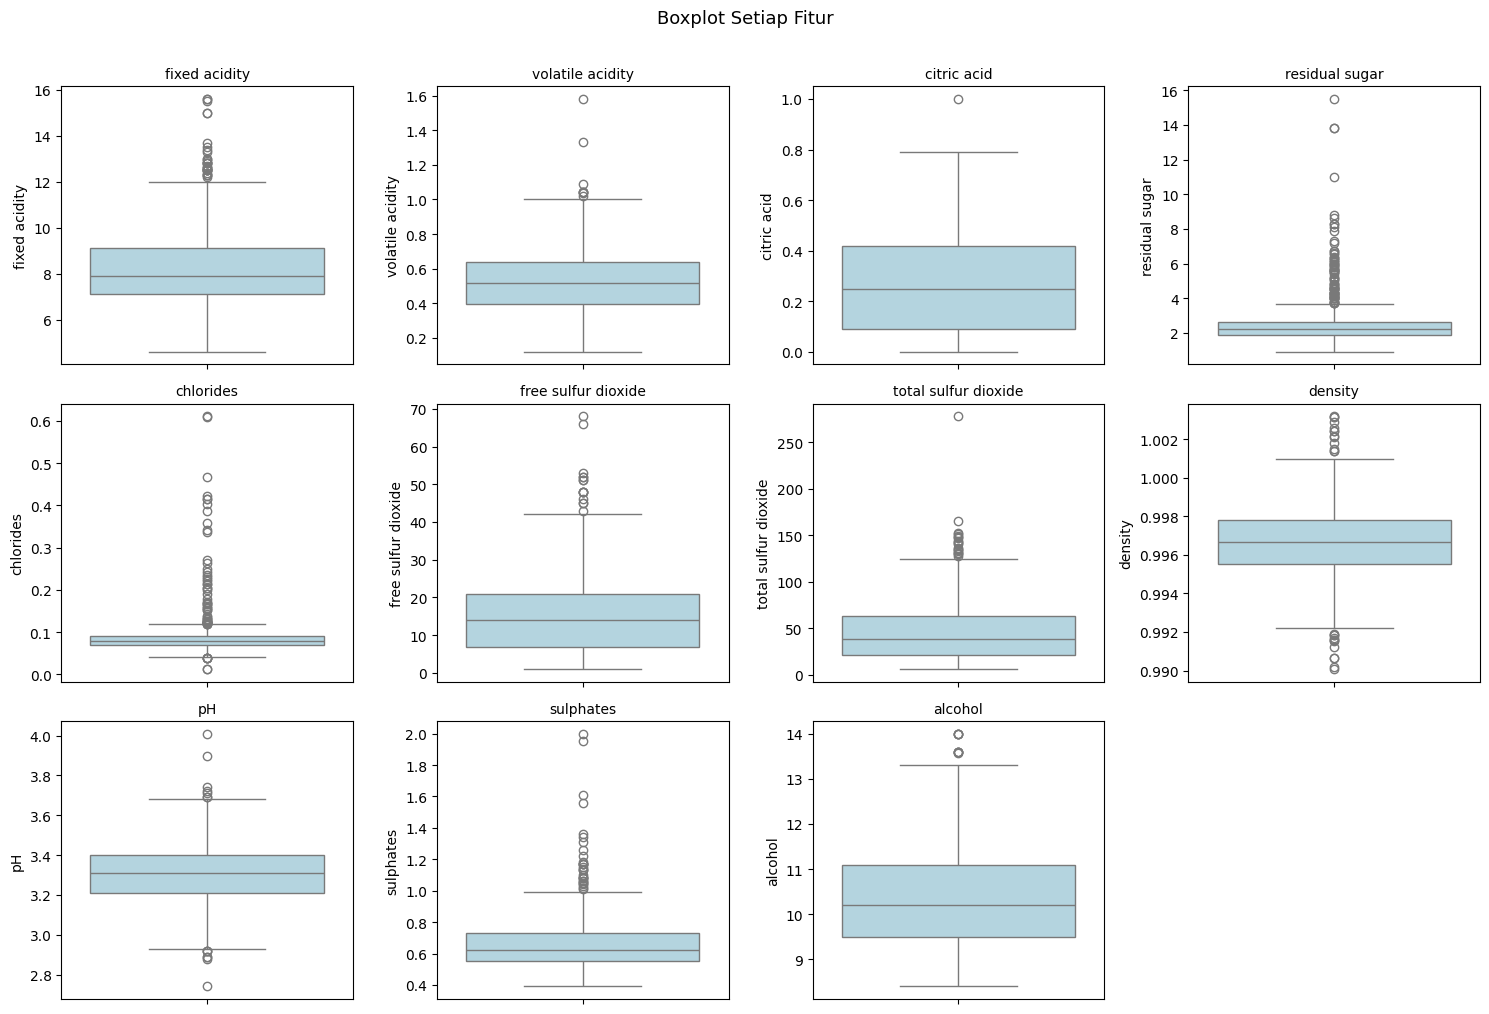

In [29]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=df_train[col], color='lightblue')
    plt.title(col, fontsize=10)
plt.suptitle('Boxplot Setiap Fitur', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

Terlihat beberapa fitur memiliki outlier cukup banyak.

Nilai ekstrem tidak langsung dihapus karena pada data kimia wine, beberapa observasi memang secara alami dapat memiliki karakteristik yang sangat berbeda dibanding sampel lainnya.

Menghapus seluruh outlier justru berisiko menghilangkan variasi asli dataset dan membuat model kehilangan kemampuan generalisasi terhadap sampel ekstrem pada data testing.

---

## 4. Persiapan Data <a name="4-persiapan"></a>

Kolom `Id` tidak memiliki nilai prediktif sehingga dikeluarkan dari matriks fitur, tetapi disimpan di variabel terpisah untuk rekonstruksi file submission.

In [30]:
X_train_raw = df_train.drop(['quality', 'Id'], axis=1)
y_train      = df_train['quality']
X_test_raw   = df_test.drop('Id', axis=1)
id_test      = df_test['Id']

print("X_train:", X_train_raw.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test_raw.shape)
print("\nKelas unik dalam y_train:", sorted(y_train.unique()))

X_train: (857, 11)
y_train: (857,)
X_test : (286, 11)

Kelas unik dalam y_train: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Kolom `Id` tidak digunakan sebagai fitur karena hanya berfungsi sebagai identitas data.

Namun kolom tersebut tetap disimpan secara terpisah karena diperlukan kembali saat pembuatan file submission.

Pemisahan feature dan target dilakukan sebelum preprocessing agar variabel target `quality` dan `Id` tidak ikut tertransformasi selama scaling maupun feature engineering.

---

## 5. Feature Engineering <a name="5-fe"></a>

### 5.1 Alasan Melakukan Feature Engineering

Walaupun algoritma ensemble berbasis tree seperti Random Forest dan Gradient Boosting mampu menangkap hubungan non-linear secara otomatis, model tetap bekerja berdasarkan pola yang tersedia pada representasi fitur yang diberikan.

Artinya, apabila hubungan penting antar variabel lebih bersifat relatif atau berbentuk rasio, maka hubungan tersebut belum tentu langsung muncul secara eksplisit hanya dari fitur asli.

Dalam konteks kualitas wine, penilaian tidak hanya dipengaruhi besar kecilnya satu komponen kimia secara terpisah, tetapi juga keseimbangan antar komponen.

Sebagai contoh:

* kadar alkohol tinggi belum tentu menghasilkan wine berkualitas baik apabila densitas cairan juga tinggi,
* sulfur dioxide total yang besar belum tentu efektif apabila proporsi sulfur aktifnya kecil,
* dan fixed acidity yang tinggi dapat memberikan karakter berbeda tergantung volatile acidity yang menyertainya.

Karena itu, feature engineering dilakukan untuk membantu model merepresentasikan hubungan relatif antar variabel yang secara domain lebih bermakna dibanding nilai absolut individual.

### 5.2 Pembuatan Fitur Baru
Tiga fitur baru dibentuk menggunakan rasio antar variabel kimia wine agar model dapat menangkap hubungan relatif yang tidak selalu terlihat langsung dari fitur asli.

#### a. `acidity_ratio`

$$\text{acidity_ratio} = \frac{\text{fixed acidity}}{\text{volatile acidity} + \varepsilon}$$

`Fixed acidity` merepresentasikan komponen asam utama yang relatif stabil pada wine, sedangkan `volatile acidity` berkaitan dengan kandungan asam volatil seperti asam asetat yang dapat menghasilkan aroma menyerupai cuka apabila terlalu tinggi.

Rasio ini digunakan untuk menggambarkan keseimbangan karakter asam wine, bukan hanya besar kecil salah satu komponen secara individual.

#### b. `sulfur_ratio`

$$\text{sulfur_ratio}=\frac{\text{free sulfur dioxide}}{\text{total sulfur dioxide}+\varepsilon}$$

`Free sulfur dioxide` merupakan bentuk sulfur yang masih aktif melindungi wine dari oksidasi dan pertumbuhan mikroorganisme.

Sebaliknya, `total sulfur dioxide` mencakup seluruh sulfur baik yang masih aktif maupun yang sudah terikat.

Karena itu, rasio ini digunakan untuk menggambarkan efektivitas sulfur dalam sistem kimia wine.

#### c. `alcohol_density_ratio`

$$\text{alcohol_density_ratio}=\frac{\text{alcohol}}{\text{density}+\varepsilon}$$

Pada tahap EDA terlihat bahwa `alcohol` dan `density` memiliki korelasi negatif cukup kuat (-0.78 dari heatmap).

Secara fisik, peningkatan kadar alkohol cenderung menurunkan densitas wine. Namun hubungan tersebut tidak selalu linear karena densitas juga dipengaruhi kandungan gula dan komponen terlarut lainnya.

Karena itu, rasio ini digunakan untuk membantu model menangkap interaksi gabungan antara kadar alkohol dan karakteristik fisik cairan secara lebih langsung.


### 5.3 Implementasi Feature Engineering

In [33]:
def add_features(df):
    df = df.copy()
    df['acidity_ratio']         = df['fixed acidity'] / (df['volatile acidity'] + 1e-9)
    df['sulfur_ratio']          = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-9)
    df['alcohol_density_ratio'] = df['alcohol'] / (df['density'] + 1e-9)
    return df

X_train_fe = add_features(X_train_raw)
X_test_fe  = add_features(X_test_raw)

print(f"Dimensi sebelum FE : {X_train_raw.shape[1]} fitur")
print(f"Dimensi setelah FE : {X_train_fe.shape[1]} fitur")
print(f"Fitur baru         : {['acidity_ratio', 'sulfur_ratio', 'alcohol_density_ratio']}")

Dimensi sebelum FE : 11 fitur
Dimensi setelah FE : 14 fitur
Fitur baru         : ['acidity_ratio', 'sulfur_ratio', 'alcohol_density_ratio']


Feature engineering menambahkan tiga fitur baru sehingga jumlah fitur meningkat dari 11 menjadi 14 variabel.

Penambahan dimensi ini masih tergolong kecil sehingga risiko curse of dimensionality atau kompleksitas ruang fitur relatif rendah dibanding potensi informasi tambahan yang diperoleh.

Selain itu, seluruh fitur baru berasal dari transformasi fitur yang sudah tersedia pada dataset asli sehingga proses ini tidak menambahkan informasi eksternal maupun menyebabkan kebocoran target.

---

## 6. Feature Scaling <a name="6-scaling"></a>

`StandardScaler` di-fit **hanya** pada data training, kemudian hasilnya digunakan untuk mentransformasi data testing. Jika scaler di-fit pada data testing juga, statistik distribusi testing (mean dan standar deviasi) akan bocor ke preprocessing sehingga kondisi evaluasi menjadi tidak valid karena model secara implisit sudah "tahu" sesuatu tentang data yang seharusnya belum dilihatnya.

In [34]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_fe), columns=X_train_fe.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_fe),      columns=X_test_fe.columns)

print(f"Mean X_train post-scaling (harusnya ~0): {X_train_scaled.mean().mean():.6f}")
print(f"Std  X_train post-scaling (harusnya ~1): {X_train_scaled.std().mean():.6f}")

Mean X_train post-scaling (harusnya ~0): 0.000000
Std  X_train post-scaling (harusnya ~1): 1.000584


Output mengonfirmasi transformasi berjalan benar. Scaling ini relevan meskipun model akhir berbasis pohon (tidak sensitif skala) karena SMOTE yang akan digunakan dalam pipeline bekerja menggunakan $k$-nearest neighbors berbasis jarak Euclidean.

Tanpa scaling, fitur dengan magnitude besar akan memiliki kontribusi dominan terhadap jarak Euclidean sehingga struktur kedekatan antar observasi menjadi bias terhadap fitur tertentu saja.

Dengan scaling, proses pencarian tetangga terdekat menjadi lebih representatif terhadap keseluruhan karakteristik kimia wine.


---

## 7. Handling Imbalanced Data dengan SMOTE <a name="7-smote"></a>

Handling Imbalanced Data dengan SMOTE tidak dilakukan sebelum cross validation karena hal tersebut dapat menyebabkan data sintetis bocor ke fold validasi.

Data leakage pada oversampling sering kali tidak terlihat secara langsung karena tidak ada target yang secara eksplisit bocor ke validation fold.

Namun ketika SMOTE dilakukan sebelum cross validation,
sampel sintetis yang dibangkitkan dari seluruh data training akan muncul dan tersebar ke semua fold, termasuk ke validation fold. Model dievaluasi pada data yang secara implisit "kenal" karena tetangga aslinya ada di training fold. Ini adalah bentuk data leakage yang menghasilkan estimasi akurasi yang terlalu optimistis.

Dengan menempatkan SMOTE di dalam `ImbPipeline`, oversampling hanya terjadi pada train fold setiap iterasi. Fold validasi selalu berisi data asli yang tidak tersentuh SMOTE, sehingga estimasi CV Accuracy benar-benar mengukur kemampuan generalisasi.

`k_neighbors=3` dipilih (bukan default 5) karena kelas 3 hanya berisi 6 sampel sehingga menggunakan `k=5` akan memunculkan error karena jumlah tetangga yang diminta melebihi jumlah sampel yang tersedia di kelas tersebut.

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('clf',   RandomForestClassifier(
                  n_estimators=300, max_depth=10, min_samples_leaf=4,
                  min_samples_split=10, max_features='sqrt',
                  class_weight='balanced', random_state=42, n_jobs=-1
              ))
])

cv_pipeline = cross_val_score(pipeline_smote, X_train_scaled, y_train,
                               cv=skf, scoring='accuracy')
print(f"SMOTE + RF — CV Accuracy: {cv_pipeline.mean():.4f} +/- {cv_pipeline.std():.4f}")

SMOTE + RF — CV Accuracy: 0.5636 +/- 0.0407


---

## 8. Perbandingan dan Pemilihan Model <a name="8-model"></a>

### 8.1 Kandidat Model

Tiga model dibandingkan untuk melihat pendekatan mana yang paling sesuai terhadap karakteristik dataset wine quality.

### a. Random Forest

Random Forest merupakan metode ensemble berbasis bagging yang membangun banyak decision tree secara independen kemudian menggabungkan prediksi melalui voting mayoritas.

Pendekatan ini efektif untuk:

* mengurangi variance model,
* meningkatkan stabilitas prediksi,
* dan menangani hubungan non-linear antar fitur.

Selain itu, Random Forest relatif robust terhadap noise dan outlier karena keputusan akhir berasal dari agregasi banyak pohon.

### b. Random Forest + SMOTE

Kombinasi ini digunakan untuk mengatasi ketidakseimbangan kelas melalui dua pendekatan sekaligus:

* `class_weight='balanced'`
* serta oversampling sintetis menggunakan SMOTE.

SMOTE diterapkan di dalam pipeline cross validation agar pembentukan sampel sintetis hanya terjadi pada train fold dan tidak menyebabkan data leakage.

### c. Gradient Boosting

Berbeda dengan Random Forest, Gradient Boosting menggunakan pendekatan boosting, yaitu membangun tree secara sekuensial di mana setiap tree baru berfokus memperbaiki kesalahan prediksi model sebelumnya.

Pendekatan ini umumnya lebih baik dalam:

* menangkap pola kompleks,
* membedakan area overlap antar kelas,
* dan mempelajari boundary keputusan yang sulit.

Namun boosting juga lebih sensitif terhadap noise apabila parameter terlalu agresif.

### 8.2 Cross Validation

In [36]:
rf_no_smote = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=4,
    min_samples_split=10, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
cv_rf = cross_val_score(rf_no_smote, X_train_scaled, y_train,
                         cv=skf, scoring='accuracy')

gb_model = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
cv_gb = cross_val_score(gb_model, X_train_scaled, y_train,
                         cv=skf, scoring='accuracy')

print(f"SMOTE + RF         : {cv_pipeline.mean():.4f} +/- {cv_pipeline.std():.4f}")
print(f"RF (tanpa SMOTE)   : {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}")
print(f"Gradient Boosting  : {cv_gb.mean():.4f} +/- {cv_gb.std():.4f}")

SMOTE + RF         : 0.5636 +/- 0.0407
RF (tanpa SMOTE)   : 0.6010 +/- 0.0351
Gradient Boosting  : 0.6290 +/- 0.0240


Evaluasi dilakukan menggunakan Stratified K-Fold Cross Validation agar proporsi kelas pada setiap fold tetap konsisten terhadap distribusi asli dataset.

### 8.3 Tabel Perbandingan Model

In [37]:
comparison_df = pd.DataFrame({
    'Model': ['SMOTE + RF', 'RF', 'Gradient Boosting'],
    'CV Accuracy': [cv_pipeline.mean(), cv_rf.mean(), cv_gb.mean()],
    'Std'        : [cv_pipeline.std(),  cv_rf.std(),  cv_gb.std()],
    'Catatan'    : [
        'Recall minoritas terlindungi via SMOTE',
        'Bias mayoritas masih lebih kuat',
        'Generalisasi terbaik antar kelas'
    ]
})
display(comparison_df)

,Model,CV Accuracy,Std,Catatan
0,SMOTE + RF,0.563620,0.040681,Recall minoritas terlindungi via SMOTE
1,RF,0.600979,0.035141,Bias mayoritas masih lebih kuat
2,Gradient Boosting,0.628975,0.024030,Generalisasi terbaik antar kelas


Hasil cross validation menunjukkan bahwa Gradient Boosting menghasilkan performa terbaik berdasarkan rata-rata CV Accuracy.

Sebaliknya, penggunaan SMOTE pada Random Forest tidak meningkatkan performa dibanding Random Forest tanpa oversampling.

Hal ini mengindikasikan bahwa kesalahan klasifikasi pada dataset wine lebih banyak disebabkan oleh overlap distribusi antar kelas dibanding sekadar ketidakseimbangan jumlah sampel.

Pada kondisi seperti ini, pembentukan sampel sintetis dari SMOTE berpotensi menghasilkan observasi tambahan pada area overlap sehingga noise klasifikasi meningkat.

Gradient Boosting lebih unggul karena mekanisme boosting secara bertahap memfokuskan pembelajaran pada observasi yang sebelumnya sulit diprediksi.

Akibatnya, model menjadi lebih mampu membedakan kelas-kelas yang memiliki karakteristik kimia mirip seperti quality 5, 6, dan 7.

In [46]:
scores = {
    'SMOTE+RF'        : cv_pipeline.mean(),
    'RF'              : cv_rf.mean(),
    'GradientBoosting': cv_gb.mean()
}
best_name = max(scores, key=scores.get)
print(f"Model terpilih: {best_name} (CV Accuracy = {scores[best_name]:.4f})")

# Latih model terpilih pada seluruh data training
final_model = gb_model
final_model.fit(X_train_scaled, y_train)
print("Model final selesai dilatih pada seluruh data training.")
print(final_model)

Model terpilih: GradientBoosting (CV Accuracy = 0.6290)
Model final selesai dilatih pada seluruh data training.
GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=300,
                           random_state=42, subsample=0.8)


---

## 9. Evaluasi Model dengan OOF <a name="9-evaluasi"></a>

### 9.1 Out-of-Fold Prediction

Setelah model dilatih pada seluruh data training, mengevaluasinya pada data yang sama tidak dapat memberikan estimasi generalisasi yang valid.

Model berbasis boosting dengan jumlah estimator besar sangat ekspresif dan cenderung menghasilkan training accuracy tinggi karena mampu mempelajari pola data training secara sangat detail.

Karena itu, metrik yang digunakan untuk evaluasi adalah Out-of-Fold (OOF) Accuracy.

`cross_val_predict` mengakumulasi prediksi dari validation fold pada setiap iterasi cross validation.

Setiap observasi diprediksi tepat satu kali ketika observasi tersebut berada pada fold validasi, sehingga model yang melakukan prediksi tidak pernah melihat observasi tersebut selama proses training.

Dengan demikian, seluruh prediksi OOF bersifat bebas dari kontaminasi in-sample dan lebih representatif terhadap kemampuan generalisasi model.

In [39]:
y_oof = cross_val_predict(
    final_model,
    X_train_scaled,
    y_train,
    cv=skf
)

oof_acc     = accuracy_score(y_train, y_oof)
f1_macro    = f1_score(y_train, y_oof, average='macro')
f1_weighted = f1_score(y_train, y_oof, average='weighted')

print(f"\nOOF Accuracy   : {oof_acc:.4f}")
print(f"F1 Macro       : {f1_macro:.4f}")
print(f"F1 Weighted    : {f1_weighted:.4f}")


OOF Accuracy   : 0.6289
F1 Macro       : 0.3573
F1 Weighted    : 0.6167


OOF Accuracy (0.63) dan F1 Macro (0.36) memiliki selisih yang cukup besar. Gap ini menunjukkan adanya ketidakseimbangan performa antar kelas.

Accuracy cenderung tinggi karena model bekerja cukup baik pada kelas mayoritas seperti kualitas 5 dan 6 yang mendominasi dataset.

Sebaliknya, F1 Macro memberikan bobot yang sama untuk setiap kelas, termasuk kelas minoritas seperti 3, 4, dan 8 yang memiliki jumlah observasi jauh lebih sedikit dan lebih sulit diprediksi.

Dengan kata lain:

* accuracy merepresentasikan performa model secara keseluruhan,
* sedangkan F1 Macro menunjukkan kemampuan model mengenali seluruh kelas secara lebih merata.

Karena dataset bersifat imbalanced, kedua metrik perlu dilaporkan bersama agar evaluasi model tidak bias terhadap kelas mayoritas saja.

### 9.2 Classification Report

In [40]:
print("Classification Report (OOF — evaluasi tidak bias):")
print(classification_report(y_train, y_oof))

Classification Report (OOF — evaluasi tidak bias):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.17      0.04      0.06        26
           5       0.68      0.73      0.71       362
           6       0.60      0.64      0.62       341
           7       0.56      0.49      0.52       109
           8       0.50      0.15      0.24        13

    accuracy                           0.63       857
   macro avg       0.42      0.34      0.36       857
weighted avg       0.61      0.63      0.62       857



Classification report memberikan evaluasi lebih rinci untuk setiap kelas melalui precision, recall, dan F1-score.

Kelas dengan jumlah observasi sangat sedikit seperti quality 3 kemungkinan memiliki recall dan F1-score rendah atau bahkan 0.00 karena model kesulitan menemukan pola yang stabil dari jumlah sampel yang sangat terbatas.

Sebaliknya, kelas 5 dan 6 cenderung memiliki performa lebih baik karena memiliki distribusi sampel terbesar pada data training.

Selain itu, sebagian besar kesalahan prediksi terjadi antar kelas yang berdekatan secara ordinal, misalnya:

* quality 5 diprediksi menjadi 6,
* atau quality 6 diprediksi menjadi 7.

Pola ini masuk akal secara domain karena karakteristik fisikokimia antar kualitas yang berdekatan memang saling overlap dan tidak memiliki batas yang benar-benar tegas.

### 9.3 Confusion Matrix OOF

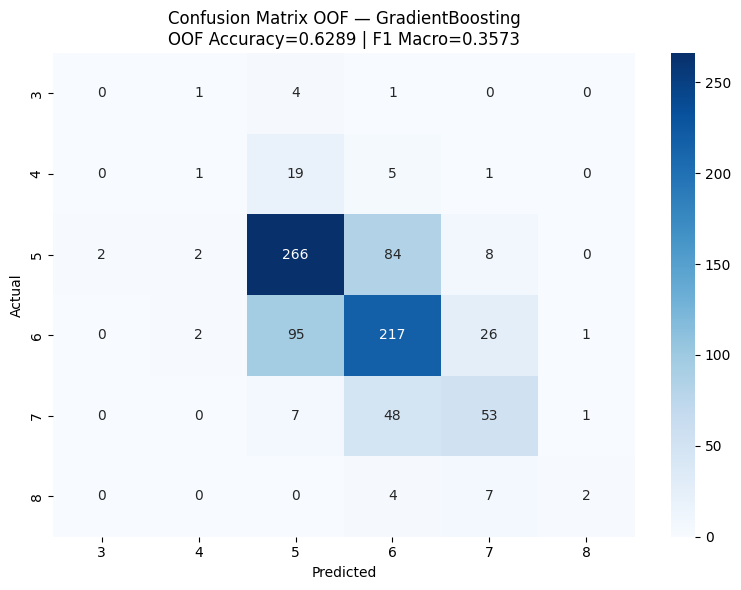

In [41]:
labels = sorted(y_train.unique())
cm = confusion_matrix(y_train, y_oof, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix OOF — {best_name}\n'
          f'OOF Accuracy={oof_acc:.4f} | F1 Macro={f1_macro:.4f}')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

Confusion matrix memperlihatkan bahwa sebagian besar prediksi benar berada pada diagonal utama.

Namun masih terdapat misklasifikasi yang cukup sering terjadi pada kelas-kelas yang berdekatan, terutama antara:

* quality 5 dan 6,
* serta quality 6 dan 7.

Sementara itu, kelas ekstrem seperti quality 3 dan 8 memiliki distribusi prediksi yang lebih menyebar.

Hal tersebut menunjukkan bahwa model memperoleh sinyal pembelajaran yang relatif terbatas untuk kelas minoritas sehingga batas keputusan model pada area tersebut menjadi kurang stabil.

Secara umum, confusion matrix mengonfirmasi bahwa tantangan utama dataset bukan hanya imbalance kelas, tetapi juga overlap distribusi antar kualitas wine.

---

## 10. Prediksi dan Submission <a name="10-prediksi"></a>

Model final yang telah dilatih menggunakan seluruh data training selanjutnya digunakan untuk memprediksi kualitas wine pada dataset testing.

Data testing menggunakan `X_test_scaled`, yaitu hasil transformasi dari scaler yang di-fit pada data training.

Pendekatan ini penting untuk menjaga konsistensi distribusi preprocessing dan menghindari data leakage dari data testing.

In [48]:
y_pred_test = final_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'Id'     : id_test.values,
    'quality': y_pred_test
})

submission.to_csv('/content/drive/Othercomputers/My Computer/Kuliah/5_Penambangan Data/M8 - UTS - 1 Mei 2026/hasilprediksi_023.csv', index=False)

print("=== Verifikasi File Submission ===")
print(f"Kolom    : {submission.columns.tolist()}")
print(f"Shape    : {submission.shape}")
print(f"\nPreview :")
display(submission.head(10))

print("\nDistribusi prediksi data testing:")
print(submission['quality'].value_counts().sort_index())

=== Verifikasi File Submission ===
Kolom    : ['Id', 'quality']
Shape    : (286, 2)

Preview :


,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
5,1120,7
6,180,5
7,82,5
8,632,5
9,592,5



Distribusi prediksi data testing:
quality
3      2
4      1
5    133
6    115
7     34
8      1
Name: count, dtype: int64


File submission diverifikasi memiliki tepat 2 kolom (`Id` dan `quality`) dan 286 baris sesuai jumlah data testing.

Distribusi prediksi pada data testing menunjukkan pola yang relatif konsisten dengan distribusi data training, di mana sebagian besar observasi diprediksi berada pada quality 5 dan 6.

Model masih menghasilkan prediksi pada kelas minoritas seperti 3, 4, dan 8 meskipun jumlahnya sangat sedikit. Hal ini menunjukkan bahwa model tidak sepenuhnya terfokus pada kelas mayoritas dan masih memiliki kemampuan dalam mengenali sebagian pola pada kelas minoritas.

Namun prediksi yang masih terkonsentrasi pada quality 5 dan 6 juga mengindikasikan bahwa overlap distribusi antar kelas masih menjadi tantangan utama dalam proses klasifikasi.

---

## 11. Feature Importance <a name="11-importance"></a>

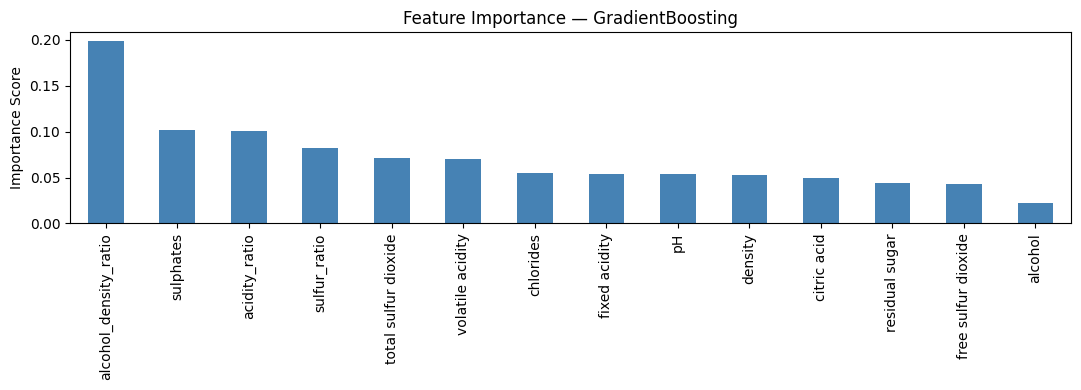

Top 5 fitur:
alcohol_density_ratio    0.198383
sulphates                0.102349
acidity_ratio            0.100905
sulfur_ratio             0.082007
total sulfur dioxide     0.071658


In [43]:
if hasattr(final_model, 'feature_importances_'):
    feat_imp = pd.Series(
        final_model.feature_importances_, index=X_train_fe.columns
    ).sort_values(ascending=False)

    feat_imp.plot(kind='bar', figsize=(11, 4), color='steelblue',
                  title=f'Feature Importance — {best_name}')
    plt.ylabel('Importance Score'); plt.tight_layout(); plt.show()

    print("Top 5 fitur:")
    print(feat_imp.head().to_string())

Feature importance digunakan untuk melihat fitur mana yang paling berkontribusi dalam proses pengambilan keputusan model.

Hasil menunjukkan bahwa fitur rekayasa seperti:

* `alcohol_density_ratio`
* `acidity_ratio`
* dan `sulfur_ratio`

justru berada pada posisi importance tertinggi.

Hal ini menunjukkan bahwa hubungan relatif antar komponen kimia wine memberikan sinyal yang lebih kuat dibanding beberapa fitur asli secara individual.

Sebagai contoh, `alcohol_density_ratio` tidak hanya merepresentasikan kadar alkohol atau densitas secara terpisah, tetapi juga menggambarkan keseimbangan antara kandungan alkohol dan karakteristik fisik wine secara simultan.

Selain fitur rekayasa, fitur asli seperti `sulphates` dan `total sulfur dioxide` juga memiliki kontribusi tinggi, yang menunjukkan bahwa kandungan sulfur tetap menjadi faktor penting dalam penentuan kualitas wine.

Dominannya fitur hasil feature engineering memberikan bukti empiris bahwa transformasi fitur berhasil menambahkan informasi baru yang membantu model memahami pola klasifikasi dengan lebih baik.

---

## 12. Kesimpulan <a name="12-kesimpulan"></a>

Dataset wine quality memiliki dua tantangan utama dalam proses klasifikasi multikelas:

* distribusi kelas yang tidak seimbang,
* serta overlap karakteristik antar kualitas wine yang berdekatan.

Untuk menangani kondisi tersebut, preprocessing dan evaluasi dirancang agar tetap realistis dan bebas dari data leakage.

Beberapa hasil utama yang diperoleh adalah sebagai berikut.

### a. Penanganan Imbalance

SMOTE ditempatkan di dalam `ImbPipeline` agar oversampling hanya dilakukan pada train fold di setiap iterasi cross validation.

Pendekatan ini mencegah kebocoran sampel sintetis ke validation fold yang dapat menghasilkan estimasi performa terlalu optimistis.

Namun pada hasil akhir, Random Forest tanpa SMOTE justru menghasilkan performa yang lebih stabil dibanding kombinasi SMOTE + Random Forest.

Hal ini menunjukkan bahwa overlap distribusi antar kelas lebih dominan sebagai sumber kesalahan dibanding imbalance jumlah sampel itu sendiri.

### b. Pemilihan Model

Berdasarkan hasil cross validation, model terbaik adalah Gradient Boosting karena menghasilkan CV Accuracy tertinggi.

Pendekatan boosting memungkinkan model memperbaiki kesalahan prediksi secara bertahap melalui pembentukan tree secara sekuensial.

Karena itu, Gradient Boosting lebih efektif dalam menangani batas kelas yang saling overlap dibanding pendekatan bagging pada Random Forest.

### c. Evaluasi Model

Evaluasi utama dilakukan menggunakan OOF Accuracy dan F1 Macro, bukan training accuracy.

OOF evaluation memberikan estimasi performa yang lebih valid karena setiap observasi diprediksi oleh model yang tidak pernah melihat observasi tersebut selama training.

Perbedaan cukup besar antara Accuracy dan F1 Macro menunjukkan bahwa model masih lebih baik dalam mengenali kelas mayoritas dibanding kelas minoritas.

Dengan demikian, accuracy saja tidak cukup untuk menggambarkan performa model pada kasus klasifikasi imbalanced.

### d. Feature Engineering

Feature engineering dilakukan dengan membangun fitur rasio berbasis hubungan antar komponen kimia wine.

Fitur seperti:

* `acidity_ratio`,
* `sulfur_ratio`,
* dan `alcohol_density_ratio`

digunakan untuk membantu model menangkap hubungan relatif antar variabel yang tidak selalu terlihat langsung dari fitur asli.

Hasil feature importance menunjukkan bahwa fitur rekayasa seperti
`alcohol_density_ratio`, `acidity_ratio`, dan `sulfur_ratio`
memberikan kontribusi penting dalam proses klasifikasi.

Hal ini menunjukkan bahwa hubungan relatif antar komponen kimia wine
mampu memberikan informasi tambahan yang tidak sepenuhnya tertangkap
oleh fitur asli secara individual.

In [44]:
sep = "=" * 55
print(f"\n{sep}")
print("RINGKASAN HASIL")
print(sep)
print(f"  Model Final    : {best_name}")
print(f"  CV Accuracy    : {scores[best_name]:.4f}")
print(f"  OOF Accuracy   : {oof_acc:.4f}")
print(f"  F1 Macro (OOF) : {f1_macro:.4f}")
print(f"  F1 Weighted    : {f1_weighted:.4f}")
print(f"  Prediksi test  : {len(submission)} baris")
print(sep)


RINGKASAN HASIL
  Model Final    : GradientBoosting
  CV Accuracy    : 0.6290
  OOF Accuracy   : 0.6289
  F1 Macro (OOF) : 0.3573
  F1 Weighted    : 0.6167
  Prediksi test  : 286 baris
